In [15]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

from src.data_loader import load_data

from src.preprocessing import (
    remove_duplicates,
    remove_empty_narratives,
    clean_narratives,
    add_word_count, 
    filter_target_products,
    categorize_products,
    clean_narratives
)

from src.eda import *
%load_ext autoreload
%autoreload 2
from src.visualization import plot_narrative_availability,plot_narrative_length,plot_product_distribution,plot_top_complaint_issues

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Dataset

In [4]:
df = load_data("../data/raw/complaints.csv")

df.head()

c:\Users\bemnet\Desktop\10academy\week7\rag-complaint-chatbot\src\data_loader.py:19: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


Dataset loaded successfully.
Rows: 9609797
Columns: 18


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


# Dataset Overview

In [5]:
dataset_summary(df)

,Data Type,Missing,Unique
Date received,str,0,4952
Product,str,0,21
Sub-product,str,235295,86
Issue,str,6,178
Sub-issue,str,839522,272
Consumer complaint narrative,str,6629041,2108758
Company public response,str,4770207,11
Company,str,0,7674
State,str,54516,63
ZIP code,str,30228,34965


# Complaint Distribution

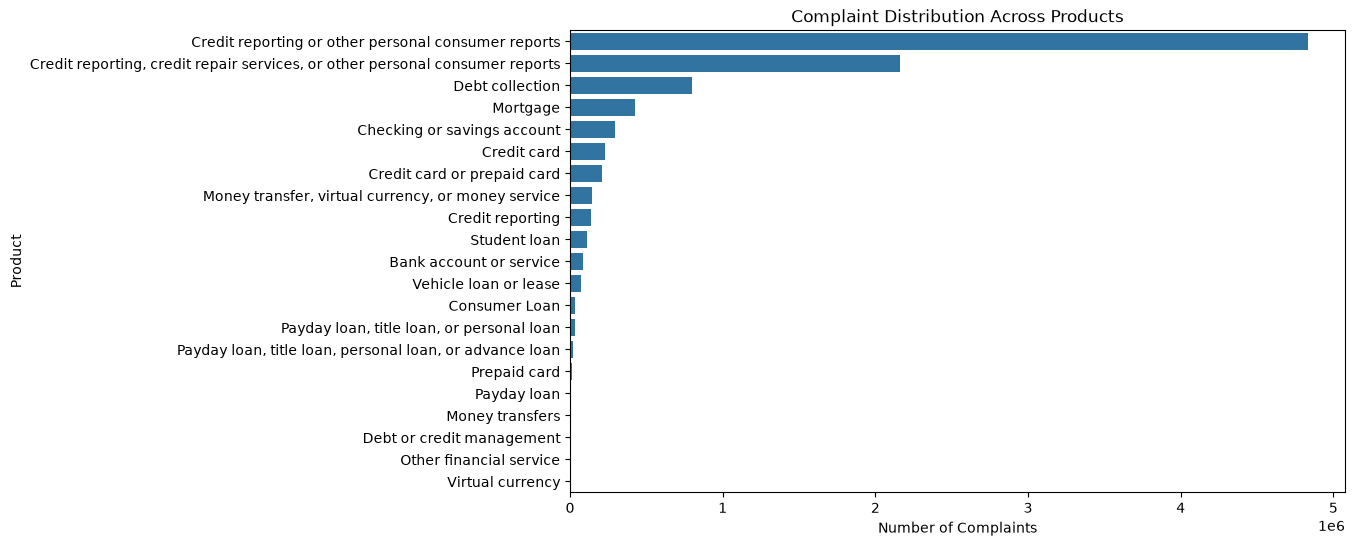

In [6]:
plot_product_distribution(df)

# Narrative Availability

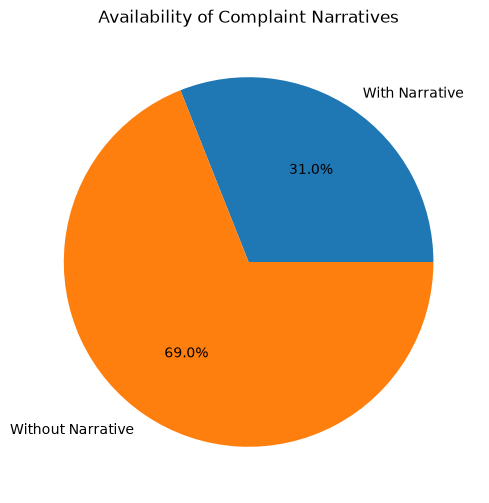

In [6]:
plot_narrative_availability(df)

# Data Cleaning

In [7]:
df = remove_duplicates(df)

df = remove_empty_narratives(df)

df = clean_narratives(df)

Removed 0 duplicate rows.
Removed 6629041 complaints without narratives.


# Top Complaint Issues

In [8]:
top_issues(df)

Issue
Incorrect information on your report                                                901091
Improper use of your report                                                         481076
Problem with a company's investigation into an existing problem                     253406
Problem with a credit reporting company's investigation into an existing problem    250397
Attempts to collect debt not owed                                                   140490
Managing an account                                                                  75712
Written notification about debt                                                      64294
Other transaction problem                                                            49431
Trouble during payment process                                                       48235
Problem with a purchase shown on your statement                                      40499
Name: count, dtype: int64

c:\Users\bemnet\Desktop\10academy\week7\rag-complaint-chatbot\src\visualization.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


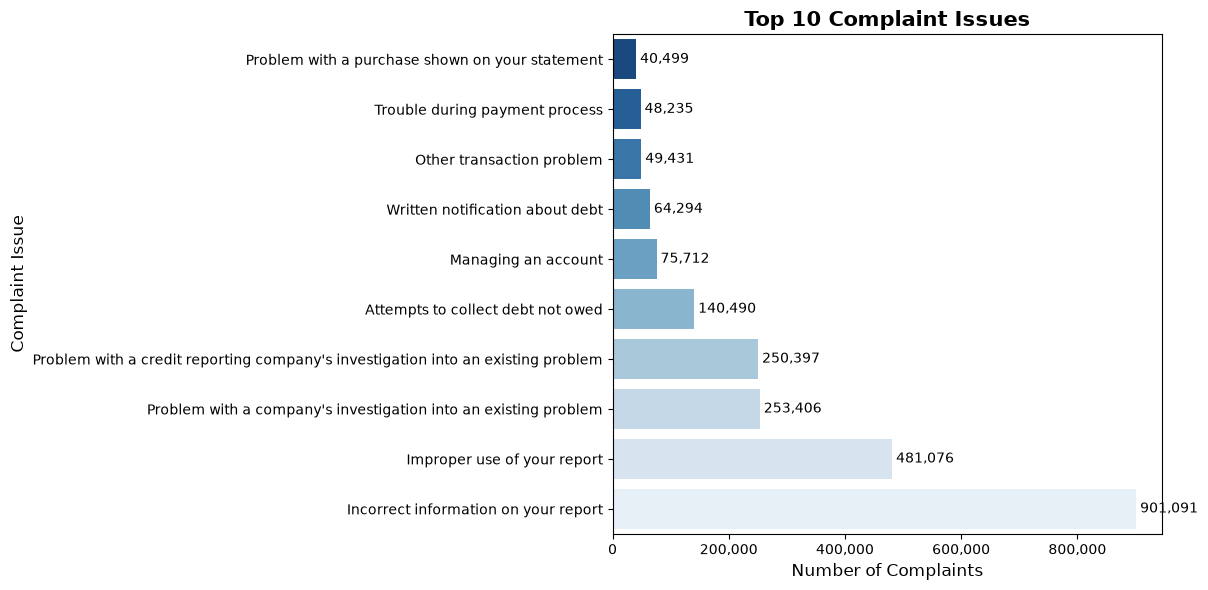

In [9]:
plot_top_complaint_issues(df)

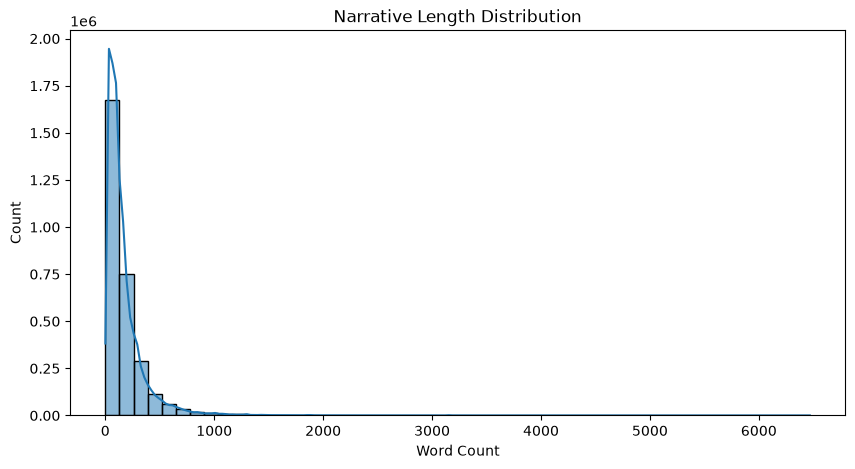

count    2.980756e+06
mean     1.755976e+02
std      2.259282e+02
min      1.000000e+00
25%      5.900000e+01
50%      1.140000e+02
75%      2.090000e+02
max      6.469000e+03
Name: word_count, dtype: float64

In [10]:
df = add_word_count(df)

plot_narrative_length(df)

narrative_statistics(df)

In [12]:
# Standardize product names
df = categorize_products(df)

In [13]:
# Keep only the required products
df = filter_target_products(df)

Removed 2,431,171 complaints from non-target products.
Remaining complaints: 549,585


In [14]:
# Verify the remaining product categories
df["Product Category"].value_counts()

Product Category
Credit Card        189334
Savings Account    140319
Personal Loan      121231
Money Transfer      98701
Name: count, dtype: int64

In [16]:
df = clean_narratives(df)

Consumer complaint narratives cleaned successfully.


In [17]:
df.to_csv("../data/processed/filtered_complaints.csv", index=False)